In [76]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [77]:
digit=load_digits()
X=digit.data
Y=digit.target

In [78]:
print("The total number of image in the dataset is ",len(digit.images))
print("The number of pixle in one image is ",digit.images[0].shape)
print("The shape of the image is ",digit.images.shape)
print("The digit is ",digit.target)

The total number of image in the dataset is  1797
The number of pixle in one image is  (8, 8)
The shape of the image is  (1797, 8, 8)
The digit is  [0 1 2 ... 8 9 8]


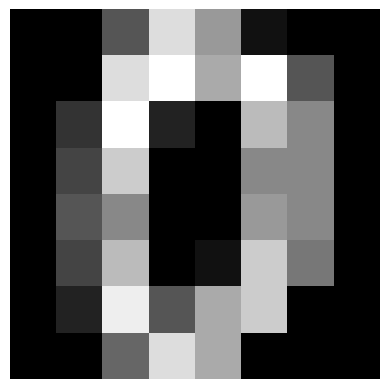

In [79]:
plt.imshow(X[0].reshape(8, 8), cmap='gray')
plt.axis('off')
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_21000\2824863559.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


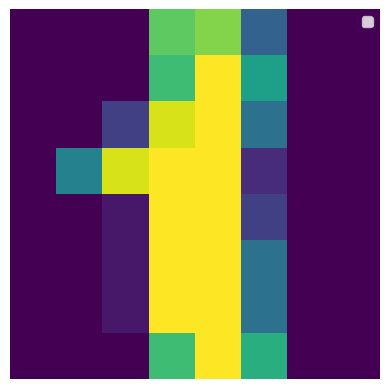

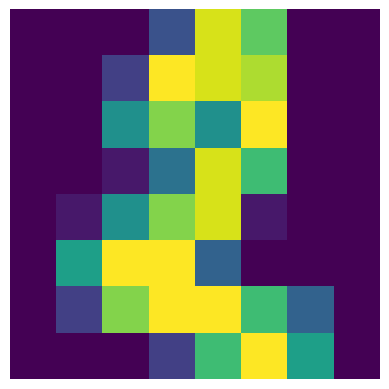

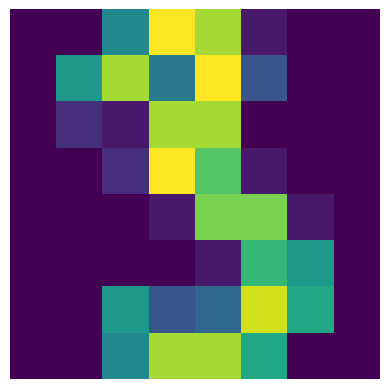

C:\Users\muham\AppData\Local\Temp\ipykernel_21000\2824863559.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


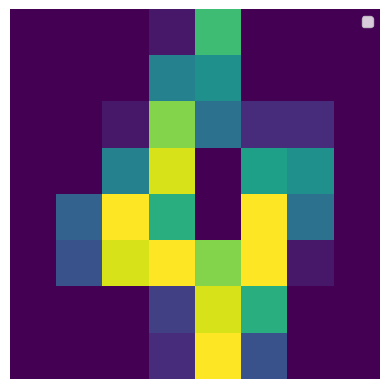

In [80]:
plt.imshow(X[1].reshape(8, 8))
plt.legend()
plt.axis('off')
plt.show()
plt.imshow(X[2].reshape(8, 8))
plt.axis('off')
plt.show();plt.imshow(X[3].reshape(8, 8))
plt.axis('off')
plt.show()
plt.imshow(X[4].reshape(8, 8))
plt.legend()
plt.axis('off')
plt.show()

### now lets vasulize the digit 

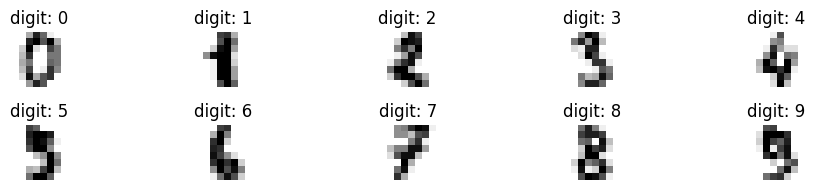

In [81]:
fig,axes=plt.subplots(2,5,figsize=(10,2))
for i, image, label in zip(axes.ravel(), digit.images, digit.target):
    i.imshow(image, cmap="gray_r")
    i.set_title(f"digit: {label}")
    i.axis("off")
plt.tight_layout()
plt.show()

In [82]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
print("for traning data............")
print("The shape of X_train is ......",X_train.shape)
print("The shape of Y_train is ......",Y_train.shape)
print()
print("for testing data..........")
print("the X_test shape is .....",X_test.shape)
print("the Y_test shape is .....",Y_test.shape)

for traning data............
The shape of X_train is ...... (1347, 64)
The shape of Y_train is ...... (1347,)

for testing data..........
the X_test shape is ..... (450, 64)
the Y_test shape is ..... (450,)


#### Train the SVM model

In [83]:
model=SVC(kernel='linear')
model.fit(X_train,Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### The model test on traning data

In [84]:
pred_traing=model.predict(X_train)
print(pred_traing)
print("the actul traing data is ",Y_train)
check_training=pd.DataFrame({
    "predction_of_model_traning":pred_traing,"Actual_label_of_traning":Y_train
})
check_training

[5 2 0 ... 2 7 1]
the actul traing data is  [5 2 0 ... 2 7 1]


,predction_of_model_traning,Actual_label_of_traning
0,5,5
1,2,2
2,0,0
3,8,8
4,7,7
...,...,...
1342,3,3
1343,7,7
1344,2,2
1345,7,7


In [85]:
acc=accuracy_score(Y_train,pred_traing)
acc

1.0

In [86]:
pred_testig=model.predict(X_test)
print(pred_testig)
print("the actul traing data is ",Y_test)
check_testing=pd.DataFrame({
    "predction_of_model_testing":pred_testig,"Actual_label_of_testing":Y_test
})
check_testing

[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8 4 3 9 7 5 6 3 5 6 3 4 9 1 4 4 6 9
 4 7 6 6 9 1 3 6 1 3 0 6 5 5 1 3 5 6 0 9 0 0 1 0 4 5 2 4 5 7 0 7 5 9 5 5 4
 7 0 4 5 5 9 9 0 2 3 8 0 6 4 4 9 1 2 8 3 5 2 9 0 4 4 4 3 5 3 1 3 5 9 4 2 7
 7 4 4 1 9 2 7 8 7 2 6 9 4 0 7 2 7 5 8 7 5 7 9 0 6 6 4 2 8 0 9 4 6 9 9 6 9
 0 5 5 6 6 0 6 4 3 9 3 7 7 2 9 0 4 5 3 6 5 9 9 8 4 2 1 3 7 7 2 2 3 9 8 0 3
 2 2 5 6 9 9 4 1 5 4 2 3 6 4 8 5 9 5 7 8 9 4 8 1 5 4 4 9 6 1 8 6 0 4 5 2 7
 1 6 4 5 6 0 3 2 3 6 7 1 5 1 4 7 6 5 8 5 5 1 6 2 8 8 9 9 7 6 2 2 2 3 4 8 8
 3 6 0 9 7 7 0 1 0 4 5 1 5 3 6 0 4 1 0 0 3 6 5 9 7 3 5 5 9 9 8 5 3 3 2 0 5
 8 3 4 0 2 4 6 4 3 4 5 0 5 2 1 3 1 4 1 1 7 0 1 5 2 1 2 8 7 0 6 4 8 8 5 1 8
 4 5 8 7 9 8 5 0 6 2 0 7 9 8 9 5 2 7 7 1 8 7 4 3 8 9 5 6 0 0 3 0 5 0 0 4 1
 2 8 4 5 9 6 3 1 8 8 4 2 3 8 9 8 8 5 0 6 3 3 7 1 6 4 1 2 1 1 6 4 7 4 8 3 4
 0 5 1 9 4 5 7 6 3 7 0 5 9 7 5 9 7 4 2 1 9 0 7 5 2 3 6 3 9 6 9 5 0 1 5 5 8
 3 3 6 2 6 5]
the actul traing data is  [6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8 4 3 9 7 5 6 3 5 6 3

,predction_of_model_testing,Actual_label_of_testing
0,6,6
1,9,9
2,3,3
3,7,7
4,2,2
...,...,...
445,3,3
446,6,6
447,2,2
448,6,6


In [87]:
acc2=accuracy_score(Y_test,pred_testig)

In [88]:
acc2

0.9822222222222222

In [89]:
image_at_index0=X_train[0].reshape(8,8)
image_at_index0
Actual_digit=Y_train[0]
Actual_digit


np.int64(5)

In [90]:
model.predict(image_at_index0.reshape(1,-1))

array([5])

5


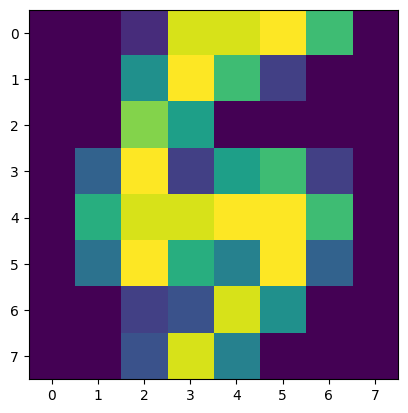

In [91]:
plt.imshow(image_at_index0)
print(Y_train[0])

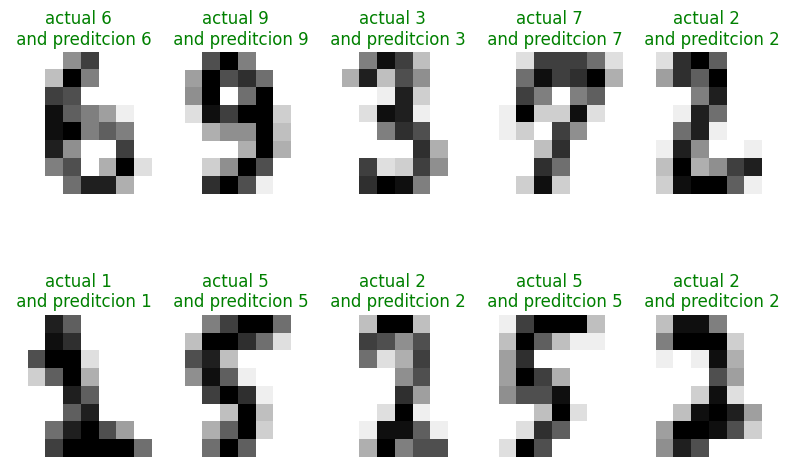

In [94]:
fig,axes=plt.subplots(2,5,figsize=(8,6))
for i,image,label,pred in zip(axes.ravel(),X_test,Y_test,pred_testig):
    i.imshow(image.reshape(8,8),cmap='gray_r')
    color = "green" if label == pred else "red"
    i.axis('off')
    i.set_title(f"actual {label} \n and preditcion {pred}",color=color)
plt.tight_layout()
plt.show()